In [1]:
import numpy as np
from numpy import array, pi, log, exp, sqrt, conj, concatenate, linspace
import numpy.linalg as linalg
from scipy.integrate import solve_ivp
from scipy.interpolate import CubicSpline
from scipy.optimize import root_scalar
import sys

def eos(rho, vec_rho, vec_p):
    for i in range(0, len(vec_rho) - 1):
        if rho <= vec_rho[0]:
            print('ERROR_1')
            break
        elif (rho > vec_rho[i]) and (rho <= vec_rho[i + 1]):
            dlogpdlogrho = log(vec_p[i + 1] / vec_p[i]) / log(vec_rho[i + 1] / vec_rho[i])
            p = vec_p[i] * ((rho / vec_rho[i]) ** dlogpdlogrho)
            Gamma = ((rho + p) / rho) * dlogpdlogrho
            return p, Gamma
        elif rho > vec_rho[-1]:
            print('ERROR_2')
            break
    return 0.0, 0.0

def eos_inv(p, vec_p, vec_rho):
    for i in range(0, len(vec_p) - 1):
        if p <= vec_p[0]:
            print('ERROR_3')
            break
        elif (p > vec_p[i]) and (p <= vec_p[i + 1]):
            dlogpdlogrho = log(vec_p[i + 1] / vec_p[i]) / log(vec_rho[i + 1] / vec_rho[i])
            rho = vec_rho[i] * ((p / vec_p[i]) ** (1.0 / dlogpdlogrho))
            Gamma = ((rho + p) / rho) * dlogpdlogrho
            return rho, Gamma
        elif p > vec_p[-1]:
            print('ERROR_4')
            break
    return 0.0, 0.0

def eos_func(eos_str):
    vec_p_tab = []
    vec_rho_tab = []
    with open(eos_str + '.txt', 'r') as file_eos:
        for line in file_eos:
            vec_p_tab.append(float(line.split()[1]))
            vec_rho_tab.append(float(line.split()[2]))
    vec_p_tab = array(vec_p_tab)
    vec_rho_tab = array(vec_rho_tab)
    vec_p = vec_p_tab * 7.4237e-19
    vec_rho = vec_rho_tab * 7.4237e-19
    return vec_p, vec_rho

def tov_func(eos_func_array, rho_0_cgs):
    def dmdr(r, rho):
        return 4.0 * pi * (r ** 2.0) * rho

    def dpdr(r, p, m, rho):
        return -((rho + p) * (m + (4.0 * pi * (r ** 3.0) * p))) / (r * (r - (2.0 * m)))

    def dnudr(r, m, p):
        return (2.0 * (m + (4.0 * pi * (r ** 3.0) * p))) / (r * (r - (2.0 * m)))

    vec_p, vec_rho = eos_func_array

    rv, mv, nuv, pv, rhov, Gammav = [], [], [], [], [], []

    rho_0 = rho_0_cgs * 7.4237e-19
    p_0, Gamma_0 = eos(rho_0, vec_rho, vec_p)
    r_0, m_0, nu_0 = 0.0, 0.0, 0.0

    rv.append(r_0); mv.append(m_0); nuv.append(nu_0)
    pv.append(p_0); rhov.append(rho_0); Gammav.append(Gamma_0)

    m_3 = 4.0 * pi * rho_0
    nu_2 = ((8.0 * pi) / 3.0) * (rho_0 + (3.0 * p_0))
    p_2 = -(((4.0 * pi) / 3.0) * (rho_0 + p_0) * (rho_0 + (3.0 * p_0)))
    rho_2 = (p_2 * (rho_0 + p_0)) / (Gamma_0 * p_0)

    r_min, dr = 1.0e-03, 1.0e-03
    r = r_min
    m = (1.0 / 3.0) * m_3 * (r ** 3.0)
    nu = nu_0 + ((1.0 / 2.0) * nu_2 * (r ** 2.0))
    p = p_0 + ((1.0 / 2.0) * p_2 * (r ** 2.0))
    rho = rho_0 + ((1.0 / 2.0) * rho_2 * (r ** 2.0))
    _, Gamma = eos(rho_0, vec_rho, vec_p)

    rv.append(r); mv.append(m); nuv.append(nu)
    pv.append(p); rhov.append(rho); Gammav.append(Gamma)

    while p >= vec_p[0]:
        s1 = dmdr(r, rho)
        s2 = dmdr(r + (dr / 2.0), rho)
        s3 = dmdr(r + (dr / 2.0), rho)
        s4 = dmdr(r + dr, rho)

        t1 = dpdr(r, p, m, rho)
        t2 = dpdr(r + (dr / 2.0), p + (t1 * (dr / 2.0)), m, rho)
        t3 = dpdr(r + (dr / 2.0), p + (t2 * (dr / 2.0)), m, rho)
        t4 = dpdr(r + dr, p + (t3 * dr), m, rho)

        u1 = dnudr(r, m, p)
        u2 = dnudr(r + (dr / 2.0), m, p)
        u3 = dnudr(r + (dr / 2.0), m, p)
        u4 = dnudr(r + dr, m, p)

        p = p + ((t1 + (2.0 * t2) + (2.0 * t3) + t4) * (dr / 6.0))
        if p < vec_p[0]:
            p = p - ((t1 + (2.0 * t2) + (2.0 * t3) + t4) * (dr / 6.0))
            break
            
        m = m + ((s1 + (2.0 * s2) + (2.0 * s3) + s4) * (dr / 6.0))
        nu = nu + ((u1 + (2.0 * u2) + (2.0 * u3) + u4) * (dr / 6.0))

        rho, Gamma = eos_inv(p, vec_p, vec_rho)
        r = r + dr

        rv.append(r); mv.append(m); nuv.append(nu)
        pv.append(p); rhov.append(rho); Gammav.append(Gamma)

    rv = array(rv); mv = array(mv); nuv = array(nuv)
    pv = array(pv); rhov = array(rhov); Gammav = array(Gammav)

    r_s = r
    m_s = m
    nu_s = log(1.0 - ((2.0 * m_s) / r_s))
    nu_0 = nu_s - nuv[-1]
    nuv = nuv + nu_0

    return rv, mv, nuv, pv, rhov, Gammav

def solve_qnm(tov_func_array, omega, ell=2.0):

    def functions_inside(t, y, tov_funcs, ell, omega):
        if t == 0.0:
            return [0.0] * 8
            
        r = t
        H1_real, K_real, W_hat_real, X_hat_real, H1_imag, K_imag, W_hat_imag, X_hat_imag = y
        H1 = H1_real + 1j * H1_imag
        K = K_real + 1j * K_imag
        W_hat = W_hat_real + 1j * W_hat_imag
        X_hat = X_hat_real + 1j * X_hat_imag

        m = tov_funcs[0](r)
        nu = tov_funcs[1](r)
        p = tov_funcs[2](r)
        rho = tov_funcs[3](r)
        gam = tov_funcs[4](r)

        lmb = -log(1.0 - (2.0 * m) / r)
        eps = rho
        nup = (2.0 * (m + (4.0 * pi * (r ** 3.0) * p))) / (r * (r - (2.0 * m)))
        pp = -((eps + p) * (m + (4.0 * pi * (r ** 3.0) * p))) / (r * (r - (2.0 * m)))

        # Perfect fluid limit implies Out of Equilibrium source terms S_** = 0.
        S_Z = 0.0
        S_00 = 0.0
        S_0 = 0.0
        S_1 = 0.0
        S_Omega = 0.0

        # Eq 40
        H0_num = -(0.5 * ell * (ell + 1.0) * (m + 4.0 * pi * r**3 * p) - (omega**2) * r**3 * exp(-lmb - nu)) * H1 \
                 + (0.5 * (ell + 2.0) * (ell - 1.0) * r - (omega**2) * r**3 * exp(-nu) - (exp(lmb) / r) * (m + 4.0 * pi * r**3 * p) * (3.0 * m - r + 4.0 * pi * r**3 * p)) * K \
                 + 8.0 * pi * r**3 * exp(-nu / 2.0) * X_hat \
                 - 8.0 * pi * r * S_0 - 16.0 * pi * r * exp(-lmb) * S_1
        H0_den = 3.0 * m + 0.5 * (ell + 2.0) * (ell - 1.0) * r + 4.0 * pi * r**3 * p
        H0 = H0_num / H0_den

        # Eq 41
        V_hat_num = X_hat \
                    - 0.5 * (eps + p) * exp(nu / 2.0) * H0 \
                    + (pp / r) * exp((nu - lmb) / 2.0) * W_hat \
                    - (exp(-lmb + nu / 2.0) / r**2) * (ell + exp(lmb) * (1.0 - 4.0 * pi * r**2 * (eps - p))) * S_1 \
                    + 0.5 * (ell**2 + ell - 2.0) / (r**2) * exp(nu / 2.0) * S_Z \
                    - (exp(nu / 2.0) / r**2) * S_Omega
        V_hat = V_hat_num / (omega**2 * (eps + p) * exp(-nu / 2.0))

        # Adiabatic relation for perfect fluid baseline setup
        cs2 = (gam * p) / (eps + p)
        E_hat = (1.0 / cs2) * X_hat

        # Eq 36
        dH1dr = (exp(lmb) / r) * H0 \
                + (4.0 * pi * r * (eps - p) * exp(lmb) - 2.0 * m * exp(lmb) / (r**2) - (ell + 1.0) / r) * H1 \
                + (exp(lmb) / r) * K \
                - 16.0 * pi * ((eps + p) / r) * exp(lmb) * V_hat \
                + 16.0 * pi * (exp(lmb) / r) * S_Z

        # Eq 37
        dKdr = (1.0 / r) * H0 \
               + (0.5 * ell * (ell + 1.0) / r) * H1 \
               + (0.5 * nup - (ell + 1.0) / r) * K \
               - 8.0 * pi * ((eps + p) / r) * exp(lmb / 2.0) * W_hat \
               + (16.0 * pi / r) * S_Z

        # Eq 38
        dWdr = 0.5 * r * exp(lmb / 2.0) * H0 \
               + r * exp(lmb / 2.0) * K \
               + (r * exp((lmb - nu) / 2.0) / (eps + p)) * E_hat \
               - ((ell + 1.0) / r) * W_hat \
               - (ell * (ell + 1.0) / r) * exp(lmb / 2.0) * V_hat \
               - (exp(lmb / 2.0) / (r * (eps + p))) * S_00 \
               + 8.0 * pi * r * exp(lmb / 2.0) * S_Z

        # Eq 39
        dXdr_perfect = - (ell / r) * X_hat \
               + 0.5 * (eps + p) * exp(nu / 2.0) * (1.0 / r - 0.5 * nup) * H0 \
               + 0.5 * (eps + p) * exp(nu / 2.0) * (omega**2 * r * exp(-nu) + 0.5 * ell * (ell + 1.0) / r) * H1 \
               + 0.5 * (eps + p) * exp(nu / 2.0) * (1.5 * nup - 1.0 / r) * K \
               - ((eps + p) / r) * exp((lmb + nu) / 2.0) * (omega**2 * exp(-nu) + (exp(-lmb) / (4.0 * r**2)) * (exp(2.0 * lmb) * (1.0 + 8.0 * pi * r**2 * p)**2 + 2.0 * exp(lmb) * (3.0 + 8.0 * pi * r**2 * p) - 7.0)) * W_hat \
               + (ell * (ell + 1.0) / (r**2)) * exp(nu / 2.0) * pp * V_hat
        
        enu2 = exp(nu / 2.0)
        elmb = exp(lmb)

        # Coefficients
        A0 = (2.0 * ell - 1.0 + elmb * (1.0 + 8.0 * pi * r**2 * p))
        A1 = (ell * (ell + 1.0) + 8.0 * pi * r**2 * (eps + p))
        dS0dr =0.0

        # Source contribution
        dXdr_source = (enu2 / (2.0 * r**3)) * A0 * S_0 \
                    + (enu2 / (r**2)) * dS0dr \
                    - (enu2 / (r**3)) * (A1 * S_1 + 2.0 * S_Omega)
        
        dXdr = dXdr_perfect + dXdr_source
        
        return [dH1dr.real, dKdr.real, dWdr.real, dXdr.real, dH1dr.imag, dKdr.imag, dWdr.imag, dXdr.imag]

    def solver_inside(t_i, t_f, y_0, tov_funcs, ell, omega):
        t_span = (t_i, t_f)
        t_eval = linspace(t_i, t_f, 5000)
        sol = solve_ivp(functions_inside, t_span, y_0, method='LSODA', t_eval=t_eval, max_step=1.0e-03, dense_output=True, args=(tov_funcs, ell, omega))
        return sol.t, sol.y[0, :], sol.y[1, :], sol.y[2, :], sol.y[3, :], sol.y[4, :], sol.y[5, :], sol.y[6, :], sol.y[7, :]

    def functions_outside(t, y, m_s, ell, omega):
        Z_real, Zp_real, Z_imag, Zp_imag = y
        Z = Z_real + 1j * Z_imag
        Zp = Zp_real + 1j * Zp_imag
        nn = 0.5 * (ell - 1.0) * (ell + 2.0)
        pot = ((1.0 - (2.0 * m_s) / t) * (2.0 * (nn**2) * (nn + 1.0) * (t**3) + 6.0 * (nn**2) * m_s * (t**2) + 18.0 * nn * (m_s**2) * t + 18.0 * (m_s**3))) / ((t**3) * (((nn * t) + 3.0 * m_s)**2))
        dZdr = Zp
        ddZdrr = -((1.0 / (1.0 - (2.0 * m_s) / t)) * (2.0 * m_s / (t**2)) * Zp) - (((1.0 / (1.0 - (2.0 * m_s) / t))**2) * (omega**2 - pot) * Z)
        return [dZdr.real, ddZdrr.real, dZdr.imag, ddZdrr.imag]

    def solver_outside(t_i, t_f, y_0, m_s, ell, omega):
        t_span = (t_i, t_f)
        t_eval = linspace(t_i, t_f, 10000)
        sol = solve_ivp(functions_outside, t_span, y_0, method='LSODA', t_eval=t_eval, max_step=1.0e-02, dense_output=True, args=(m_s, ell, omega))
        return sol.t, sol.y[0, :], sol.y[1, :], sol.y[2, :], sol.y[3, :]

    rv, mv, nuv, pv, rhov, Gammav = tov_func_array
    r_0, r_s, nu_0, p_0, rho_0 = rv[0], rv[-1], nuv[0], pv[0], rhov[0]

    tov_funcs = [CubicSpline(rv, mv), CubicSpline(rv, nuv), CubicSpline(rv, pv), CubicSpline(rv, rhov), CubicSpline(rv, Gammav)]

    # Forward 1
    K_0 = +(rho_0 + p_0)
    W_0 = 1.0
    X_0 = (rho_0 + p_0) * exp(nu_0 / 2.0) * (((((4.0 * pi) / 3.0) * (rho_0 + 3.0 * p_0)) - (omega**2 / (exp(nu_0) * ell))) * W_0 + 0.5 * K_0)
    H1_0 = (2.0 * ell * K_0 + 16.0 * pi * (rho_0 + p_0) * W_0) / (ell * (ell + 1.0))
    y_0 = [H1_0.real, K_0.real, W_0.real, X_0.real, H1_0.imag, K_0.imag, W_0.imag, X_0.imag]
    all_vars = solver_inside(r_0, 0.5 * r_s, y_0, tov_funcs, ell, omega)
    r4_vec = all_vars[0]
    H14 = all_vars[1][-1] + 1j * all_vars[5][-1]
    K4 = all_vars[2][-1] + 1j * all_vars[6][-1]
    W4 = all_vars[3][-1] + 1j * all_vars[7][-1]
    X4 = all_vars[4][-1] + 1j * all_vars[8][-1]

    # Forward 2
    K_0 = -(rho_0 + p_0)
    W_0 = 1.0
    X_0 = (rho_0 + p_0) * exp(nu_0 / 2.0) * (((((4.0 * pi) / 3.0) * (rho_0 + 3.0 * p_0)) - (omega**2 / (exp(nu_0) * ell))) * W_0 + 0.5 * K_0)
    H1_0 = (2.0 * ell * K_0 + 16.0 * pi * (rho_0 + p_0) * W_0) / (ell * (ell + 1.0))
    y_0 = [H1_0.real, K_0.real, W_0.real, X_0.real, H1_0.imag, K_0.imag, W_0.imag, X_0.imag]
    all_vars = solver_inside(r_0, 0.5 * r_s, y_0, tov_funcs, ell, omega)
    H15 = all_vars[1][-1] + 1j * all_vars[5][-1]
    K5 = all_vars[2][-1] + 1j * all_vars[6][-1]
    W5 = all_vars[3][-1] + 1j * all_vars[7][-1]
    X5 = all_vars[4][-1] + 1j * all_vars[8][-1]

    # Backward 1
    y_s = [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
    all_vars = solver_inside(r_s, 0.5 * r_s, y_s, tov_funcs, ell, omega)
    r1_vec = all_vars[0]
    H11 = all_vars[1][-1] + 1j * all_vars[5][-1]
    K1 = all_vars[2][-1] + 1j * all_vars[6][-1]
    W1 = all_vars[3][-1] + 1j * all_vars[7][-1]
    X1 = all_vars[4][-1] + 1j * all_vars[8][-1]

    # Backward 2
    y_s = [0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
    all_vars = solver_inside(r_s, 0.5 * r_s, y_s, tov_funcs, ell, omega)
    H12 = all_vars[1][-1] + 1j * all_vars[5][-1]
    K2 = all_vars[2][-1] + 1j * all_vars[6][-1]
    W2 = all_vars[3][-1] + 1j * all_vars[7][-1]
    X2 = all_vars[4][-1] + 1j * all_vars[8][-1]

    # Backward 3
    y_s = [0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]
    all_vars = solver_inside(r_s, 0.5 * r_s, y_s, tov_funcs, ell, omega)
    H13 = all_vars[1][-1] + 1j * all_vars[5][-1]
    K3 = all_vars[2][-1] + 1j * all_vars[6][-1]
    W3 = all_vars[3][-1] + 1j * all_vars[7][-1]
    X3 = all_vars[4][-1] + 1j * all_vars[8][-1]

    arr_A = array([[H11, H12, H13, H14], [K1, K2, K3, K4], [W1, W2, W3, W4], [X1, X2, X3, X4]])
    arr_B = array([H15, K5, W5, X5])
    arr_inv_A = linalg.inv(arr_A)
    arr_a = arr_inv_A.dot(arr_B)

    a_1, a_2, a_3 = arr_a[0], arr_a[1], arr_a[2]
    
    H1_out_s = a_1*1.0 + a_2*0.0 + a_3*0.0
    K_out_s  = a_1*0.0 + a_2*1.0 + a_3*0.0
    W_out_s  = a_1*0.0 + a_2*0.0 + a_3*1.0
    X_out_s  = 0.0 + 0j
    
    m_s, nu_s, p_s, rho_s = mv[-1], nuv[-1], pv[-1], rhov[-1]
    lmb_s = -log(1.0 - (2.0 * m_s) / r_s)
    
    Ks = K_out_s
    H0s = (((8.0 * pi * r_s**3 * exp(-nu_s / 2.0)) * X_out_s) - (((3.0 * (m_s + 4.0 * pi * r_s**3 * p_s)) - (omega**2 * r_s**3 * exp(-(lmb_s + nu_s)))) * H1_out_s) + (((2.0 * r_s) - (omega**2 * r_s**3 * exp(-nu_s)) - ((exp(lmb_s) / r_s) * (m_s + 4.0 * pi * r_s**3 * p_s) * (3.0 * m_s - r_s + 4.0 * pi * r_s**3 * p_s))) * K_out_s)) / (3.0 * m_s + 2.0 * r_s + 4.0 * pi * r_s**3 * p_s)

    nn = 0.5 * (ell - 1.0) * (ell + 2.0)
    aas = -((nn * r_s) + 3.0 * m_s) / ((omega**2 * r_s**2) - ((nn + 1.0) * m_s) / r_s)
    bbs = ((nn * r_s * (r_s - 2.0 * m_s)) - (omega**2 * r_s**4) + m_s * (r_s - 3.0 * m_s)) / ((r_s - 2.0 * m_s) * ((omega**2 * r_s**2) - ((nn + 1.0) * m_s) / r_s))
    ggs = ((nn * (nn + 1.0) * r_s**2) + 3.0 * nn * m_s * r_s + 6.0 * m_s**2) / (r_s**2 * (nn * r_s + 3.0 * m_s))
    hhs = (-(nn * r_s**2) + 3.0 * nn * m_s * r_s + 3.0 * m_s**2) / ((r_s - 2.0 * m_s) * (nn * r_s + 3.0 * m_s))
    kks = -(r_s**2) / (r_s - 2.0 * m_s)

    Zs = ((kks * Ks) - (aas * H0s) - (bbs * Ks)) / ((kks * ggs) - hhs)
    Zps = (1.0 / (1.0 - (2.0 * m_s) / r_s)) * (((hhs * Ks) - (aas * ggs * H0s) - (bbs * ggs * Ks)) / (hhs - kks * ggs))

    if r_s <= 4.0 * m_s:
        a = 4.0 * m_s * 1.01
        y_0 = [Zs.real, Zps.real, Zs.imag, Zps.imag]
        all_vars_out = solver_outside(r_s, a, y_0, m_s, ell, omega)
        Zs = all_vars_out[1][-1] + 1j * all_vars_out[3][-1]
        Zps = (all_vars_out[2][-1] + 1j * all_vars_out[4][-1]) * (1.0 / (1.0 - (2.0 * m_s) / a))
    else:
        a = r_s
        Zps = Zps / (1.0 / (1.0 - (2.0 * m_s) / r_s))

    lbd = (ell * (ell + 1.0) / 2.0) - 1.0
    beta = 6.0 * m_s
    kappa = 4.0 * lbd * (lbd + 1.0)
    f_s = (a - 2.0 * m_s) / (2.0 * a**2 * (lbd * a + 3.0 * m_s))

    Qs = (((kappa + 2.0 * beta**2 * f_s) * Zs) - 2.0 * beta * Zps) / (kappa - 2.0 * 1j * omega * beta)
    Qps = (((kappa + 2.0 * 1j * omega * beta) * Zs) - ((kappa + 2.0 * beta**2 * f_s) * Qs)) / (2.0 * beta)
    Qps = Qps * (1.0 / (1.0 - (2.0 * m_s) / a))

    chi_a = (1.0 / (((a / (2.0 * m_s)) - 1.0)**(1j * 2.0 * m_s * omega))) * (1.0 / exp(1j * omega * a))
    a0 = Qs / chi_a
    a1 = (a / chi_a) * (Qps + ((1j * omega * a) / (a - 2.0 * m_s)) * Qs)

    alpha_vec, beta_vec, gamma_vec, delta_vec = [], [], [], []
    for n in range(10):
        alpha = (1.0 - (2.0 * m_s) / a) * n * (n + 1.0)
        beta_ = -2.0 * ((1j * omega * a) + (1.0 - (3.0 * m_s) / a) * n) * n
        gamma = (1.0 - (6.0 * m_s) / a) * n * (n - 1.0) + (6.0 * m_s) / a - ell * (ell + 1.0)
        delta = ((2.0 * m_s) / a) * (n - 3.0) * (n + 1.0)
        alpha_vec.append(alpha); beta_vec.append(beta_); gamma_vec.append(gamma); delta_vec.append(delta)

    alpha_tilde_vec, beta_tilde_vec, gamma_tilde_vec = [-1.0], [a1 / a0 if a0 != 0 else 1e9], [0.0]
    alpha_tilde_vec.append(alpha_vec[1]); beta_tilde_vec.append(beta_vec[1]); gamma_tilde_vec.append(gamma_vec[1])
    for n in range(2, 10):
        alpha_tilde = alpha_vec[n]
        if gamma_tilde_vec[n - 1] != 0:
            beta_tilde = beta_vec[n] - ((alpha_tilde_vec[n - 1] * delta_vec[n]) / gamma_tilde_vec[n - 1]) 
            gamma_tilde = gamma_vec[n] - ((beta_tilde_vec[n - 1] * delta_vec[n]) / gamma_tilde_vec[n - 1]) 
        else:
            beta_tilde = 1e9; gamma_tilde = 1e9
        alpha_tilde_vec.append(alpha_tilde); beta_tilde_vec.append(beta_tilde); gamma_tilde_vec.append(gamma_tilde)

    f_0 = (beta_tilde_vec[0]-((alpha_tilde_vec[0]*gamma_tilde_vec[1])/\
          (beta_tilde_vec[1]-((alpha_tilde_vec[1]*gamma_tilde_vec[2])/\
          (beta_tilde_vec[2]-((alpha_tilde_vec[2]*gamma_tilde_vec[3])/\
          (beta_tilde_vec[3]-((alpha_tilde_vec[3]*gamma_tilde_vec[4])/\
          (beta_tilde_vec[4]-((alpha_tilde_vec[4]*gamma_tilde_vec[5])/\
          (beta_tilde_vec[5]-((alpha_tilde_vec[5]*gamma_tilde_vec[6])/\
          (beta_tilde_vec[6]-((alpha_tilde_vec[6]*gamma_tilde_vec[7])/\
          (beta_tilde_vec[7]-((alpha_tilde_vec[7]*gamma_tilde_vec[8])/\
          (beta_tilde_vec[8]-((alpha_tilde_vec[8]*gamma_tilde_vec[9])/\
          (beta_tilde_vec[9]
          )))))))))))))))))))
    return f_0

def muller_func(omega_1, omega_2, omega_3, gama_1, gama_2, gama_3):
    pts = [(omega_1, gama_1), (omega_2, gama_2), (omega_3, gama_3)]
    pts.sort(key=lambda x: abs(x[1]), reverse=True)
    z_1, f_1 = pts[0]; z_2, f_2 = pts[1]; z_3, f_3 = pts[2]

    q = (z_3 - z_2) / (z_2 - z_1)
    aa = (q * f_3) - (q * (1.0 + q) * f_2) + (q**2 * f_1)
    bb = (((2.0 * q) + 1.0) * f_3) - (((1.0 + q)**2) * f_2) + (q**2 * f_1)
    cc = (1.0 + q) * f_3
    dd = bb**2 - 4.0 * aa * cc

    if abs(bb + sqrt(dd)) > abs(bb - sqrt(dd)):
        z_4 = z_3 - ((z_3 - z_2) * ((2.0 * cc) / (bb + sqrt(dd))))
    else:
        z_4 = z_3 - ((z_3 - z_2) * ((2.0 * cc) / (bb - sqrt(dd))))

    return z_2, z_3, z_4, abs(f_3)

def search_frequency(omega_guess, tov_func_array, max_iters=20, tol=1e-8):
    omega_1 = omega_guess * 0.9
    omega_2 = omega_guess * 1.0
    omega_3 = omega_guess * 1.1

    gama_1 = solve_qnm(tov_func_array, omega_1)
    gama_2 = solve_qnm(tov_func_array, omega_2)
    gama_3 = solve_qnm(tov_func_array, omega_3)

    omega_r_bf = omega_guess.real
    delta_abs = 1.0
    iters = 0

    while delta_abs > tol and iters < max_iters:
        omega_1, omega_2, omega_3, gama_abs = muller_func(omega_1, omega_2, omega_3, gama_1, gama_2, gama_3)
        gama_1 = solve_qnm(tov_func_array, omega_1)
        gama_2 = solve_qnm(tov_func_array, omega_2)
        gama_3 = solve_qnm(tov_func_array, omega_3)

        delta_abs = abs(1.0 - (omega_3.real / omega_r_bf)) if omega_r_bf != 0 else 1.0
        omega_r_bf = omega_3.real
        iters += 1
        print(f"Iter {iters}: omega = {omega_3}, del_res = {delta_abs:.2e}")

    return omega_3

def get_rho0_for_compactness(target_C, eos_str):
    eos_func_array = eos_func(eos_str)
    
    def C_diff(log_rho0):
        tov = tov_func(eos_func_array, 10**log_rho0)
        M, R = tov[1][-1], tov[0][-1]
        return (M / R) - target_C
    
    res = root_scalar(C_diff, bracket=[14.4, 15.6], method='brentq', xtol=1e-5)
    return 10**res.root



In [4]:
eos_str = 'SLy4'

target_compactnesses = [0.15, 0.20]

for C in target_compactnesses:
    print(f"\n===========================")
    print(f"--- Target Compactness: {C} ---")
    rho_0 = get_rho0_for_compactness(C, eos_str)
    print(f"Required Central Density: {rho_0:.4e} g/cm^3")
    
    tov_array = tov_func(eos_func(eos_str), rho_0)
    M = tov_array[1][-1]
    
    # 1. f-mode guess (Standard TL fit)
    a_f = 0.15 - 1j*5.8e-04
    b_f = 0.56 + 1j*6.7e-04
    c_f = -0.020 - 1j*6.2e-05
    omega_guess_f = (1.0/M) * (a_f*(C**2.0) + b_f*C + c_f)
    
    # 2. First polar w-mode guess (from Universality in QNMs)
    a_pw1 = -8.2 - 1j*10.0
    b_pw1 = 3.9 + 1j*3.3
    c_pw1 = 0.055 + 1j*0.043
    omega_guess_pw1 = (1.0/M) * (a_pw1*(C**2.0) + b_pw1*C + c_pw1)

    print("\n> Searching f-mode...")
    try:
        omega_f = search_frequency(omega_guess_f, tov_array)
        print(f"Result f-mode: {omega_f}")
    except Exception as e:
        print(f"Failed to converge f-mode: {e}")

    print("\n> Searching w1-mode...")
    try:
        omega_pw1 = search_frequency(omega_guess_pw1, tov_array)
        print(f"Result w1-mode: {omega_pw1}")
    except Exception as e:
        print(f"Failed to converge w1-mode: {e}")



--- Target Compactness: 0.15 ---
Required Central Density: 8.4962e+14 g/cm^3

> Searching f-mode...
Iter 1: omega = (0.038215687309018954+1.3165812853911214e-05j), del_res = 5.40e-03
Iter 2: omega = (0.038220627652094954+1.3148047903299984e-05j), del_res = 1.29e-04
Iter 3: omega = (0.03822056933041282+1.3148017304733632e-05j), del_res = 1.53e-06
Iter 4: omega = (0.03822059040820993+1.3148033352684011e-05j), del_res = 5.51e-07
Iter 5: omega = (0.038220589998237936+1.3148034638178476e-05j), del_res = 1.07e-08
Iter 6: omega = (0.03822059032454705+1.3148033876080816e-05j), del_res = 8.54e-09
Result f-mode: (0.03822059032454705+1.3148033876080816e-05j)

> Searching w1-mode...
Iter 1: omega = (0.25729814048824134+0.17293828600517028j), del_res = 1.25e-03
Iter 2: omega = (0.25659029315910936+0.1730473377554389j), del_res = 2.75e-03
Iter 3: omega = (0.2566673314160072+0.1730419393400545j), del_res = 3.00e-04
Iter 4: omega = (0.25668846566133335+0.1730460483987917j), del_res = 8.23e-05
Iter 5:

KeyboardInterrupt: 

# Modified run

In [1]:
import numpy as np
from numpy import array, pi, log, exp, sqrt, conj, concatenate, linspace
import numpy.linalg as linalg
from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar
import matplotlib.pyplot as plt
import sys
from numba import njit

@njit(fastmath=True)
def eos_njit(rho, vec_rho, vec_p):
    if rho <= vec_rho[0]:
        return 0.0, 0.0
    if rho >= vec_rho[-1]:
        return vec_p[-1], 0.0
    idx = np.searchsorted(vec_rho, rho)
    if idx == 0: idx = 1
    i = idx - 1
    
    dlogp = np.log(vec_p[i + 1] / vec_p[i])
    dlogrho = np.log(vec_rho[i + 1] / vec_rho[i])
    if dlogrho == 0.0: dlogpdlogrho = 0.0
    else: dlogpdlogrho = dlogp / dlogrho
    
    p = vec_p[i] * ((rho / vec_rho[i]) ** dlogpdlogrho)
    Gamma = ((rho + p) / rho) * dlogpdlogrho
    return p, Gamma

@njit(fastmath=True)
def eos_inv_njit(p, vec_p, vec_rho):
    if p <= vec_p[0]:
        return 0.0, 0.0
    if p >= vec_p[-1]:
        return vec_rho[-1], 0.0
    idx = np.searchsorted(vec_p, p)
    if idx == 0: idx = 1
    i = idx - 1
    
    dlogp = np.log(vec_p[i + 1] / vec_p[i])
    dlogrho = np.log(vec_rho[i + 1] / vec_rho[i])
    if dlogrho == 0.0: dlogpdlogrho = 1.0
    else: dlogpdlogrho = dlogp / dlogrho
    
    rho = vec_rho[i] * ((p / vec_p[i]) ** (1.0 / dlogpdlogrho))
    Gamma = ((rho + p) / rho) * dlogpdlogrho
    return rho, Gamma

@njit(fastmath=True)
def tov_loop_njit(p_0, rho_0, Gamma_0, r_min, dr, vec_p, vec_rho):
    rv = np.zeros(200000)
    mv = np.zeros(200000)
    nuv = np.zeros(200000)
    pv = np.zeros(200000)
    rhov = np.zeros(200000)
    Gammav = np.zeros(200000)

    m_3 = 4.0 * np.pi * rho_0
    nu_2 = ((8.0 * np.pi) / 3.0) * (rho_0 + (3.0 * p_0))
    p_2 = -(((4.0 * np.pi) / 3.0) * (rho_0 + p_0) * (rho_0 + (3.0 * p_0)))
    rho_2 = (p_2 * (rho_0 + p_0)) / (Gamma_0 * p_0)

    r = r_min
    m = (1.0 / 3.0) * m_3 * (r ** 3.0)
    nu = 0.0 + ((1.0 / 2.0) * nu_2 * (r ** 2.0))
    p = p_0 + ((1.0 / 2.0) * p_2 * (r ** 2.0))
    rho = rho_0 + ((1.0 / 2.0) * rho_2 * (r ** 2.0))
    _, Gamma = eos_njit(rho_0, vec_rho, vec_p)

    rv[0] = r; mv[0] = m; nuv[0] = nu; pv[0] = p; rhov[0] = rho; Gammav[0] = Gamma

    idx = 0
    while p >= vec_p[0] and idx < 199999:
        s1 = 4.0 * np.pi * (r ** 2.0) * rho
        s2 = 4.0 * np.pi * ((r + (dr / 2.0)) ** 2.0) * rho
        s3 = s2
        s4 = 4.0 * np.pi * ((r + dr) ** 2.0) * rho

        t1 = -((rho + p) * (m + (4.0 * np.pi * (r ** 3.0) * p))) / (r * (r - (2.0 * m)))
        
        p_t2 = p + (t1 * (dr / 2.0))
        t2 = -((rho + p_t2) * (m + (4.0 * np.pi * ((r + (dr / 2.0)) ** 3.0) * p_t2))) / ((r + (dr / 2.0)) * ((r + (dr / 2.0)) - (2.0 * m)))
        
        p_t3 = p + (t2 * (dr / 2.0))
        t3 = -((rho + p_t3) * (m + (4.0 * np.pi * ((r + (dr / 2.0)) ** 3.0) * p_t3))) / ((r + (dr / 2.0)) * ((r + (dr / 2.0)) - (2.0 * m)))
        
        p_t4 = p + (t3 * dr)
        t4 = -((rho + p_t4) * (m + (4.0 * np.pi * ((r + dr) ** 3.0) * p_t4))) / ((r + dr) * ((r + dr) - (2.0 * m)))

        u1 = (2.0 * (m + (4.0 * np.pi * (r ** 3.0) * p))) / (r * (r - (2.0 * m)))
        u2 = (2.0 * (m + (4.0 * np.pi * ((r + (dr / 2.0)) ** 3.0) * p))) / ((r + (dr / 2.0)) * ((r + (dr / 2.0)) - (2.0 * m)))
        u3 = u2
        u4 = (2.0 * (m + (4.0 * np.pi * ((r + dr) ** 3.0) * p))) / ((r + dr) * ((r + dr) - (2.0 * m)))

        p_new = p + ((t1 + (2.0 * t2) + (2.0 * t3) + t4) * (dr / 6.0))
        if p_new < vec_p[0]:
            p_new = p - ((t1 + (2.0 * t2) + (2.0 * t3) + t4) * (dr / 6.0))
            break
            
        p = p_new
        m = m + ((s1 + (2.0 * s2) + (2.0 * s3) + s4) * (dr / 6.0))
        nu = nu + ((u1 + (2.0 * u2) + (2.0 * u3) + u4) * (dr / 6.0))
        
        rho, Gamma = eos_inv_njit(p, vec_p, vec_rho)
        r = r + dr

        idx += 1
        rv[idx] = r; mv[idx] = m; nuv[idx] = nu; pv[idx] = p; rhov[idx] = rho; Gammav[idx] = Gamma

    return rv[:idx+1], mv[:idx+1], nuv[:idx+1], pv[:idx+1], rhov[:idx+1], Gammav[:idx+1]

def eos_func(eos_str):
    vec_p_tab = []
    vec_rho_tab = []
    with open(eos_str + '.txt', 'r') as file_eos:
        for line in file_eos:
            vec_p_tab.append(float(line.split()[1]))
            vec_rho_tab.append(float(line.split()[2]))
    vec_p = array(vec_p_tab) * 7.4237e-19
    vec_rho = array(vec_rho_tab) * 7.4237e-19
    return vec_p, vec_rho

def tov_func(eos_func_array, rho_0_cgs):
    vec_p, vec_rho = eos_func_array
    rho_0 = rho_0_cgs * 7.4237e-19
    p_0, Gamma_0 = eos_njit(rho_0, vec_rho, vec_p)
    r_min, dr = 1.0e-03, 1.0e-03

    rv, mv, nuv, pv, rhov, Gammav = tov_loop_njit(p_0, rho_0, Gamma_0, r_min, dr, vec_p, vec_rho)

    r_s = rv[-1]
    m_s = mv[-1]
    nu_s = log(1.0 - ((2.0 * m_s) / r_s))
    nu_0 = nu_s - nuv[-1]
    nuv = nuv + nu_0

    return rv, mv, nuv, pv, rhov, Gammav

from scipy.interpolate import CubicSpline

@njit(fastmath=True)
def _compute_derivatives_inside(r, y, m, nu, p, eps, gam, ell, omegaR, omegaI):
    omega = omegaR + 1j * omegaI
    
    H1_real, K_real, W_hat_real, X_hat_real, H1_imag, K_imag, W_hat_imag, X_hat_imag = y[0], y[1], y[2], y[3], y[4], y[5], y[6], y[7]
    H1 = H1_real + 1j * H1_imag
    K = K_real + 1j * K_imag
    W_hat = W_hat_real + 1j * W_hat_imag
    X_hat = X_hat_real + 1j * X_hat_imag

    lmb = -np.log(1.0 - (2.0 * m) / r)
    nup = (2.0 * (m + (4.0 * np.pi * (r ** 3.0) * p))) / (r * (r - (2.0 * m)))
    pp = -((eps + p) * (m + (4.0 * np.pi * (r ** 3.0) * p))) / (r * (r - (2.0 * m)))

    S_Z = 0.0 + 0j
    S_00 = 0.0 + 0j
    S_0 = 0.0 + 0j
    S_1 = 0.0 + 0j
    S_Omega = 0.0 + 0j

    H0_num = -(0.5 * ell * (ell + 1.0) * (m + 4.0 * np.pi * r**3 * p) - (omega**2) * r**3 * np.exp(-lmb - nu)) * H1 \
             + (0.5 * (ell + 2.0) * (ell - 1.0) * r - (omega**2) * r**3 * np.exp(-nu) - (np.exp(lmb) / r) * (m + 4.0 * np.pi * r**3 * p) * (3.0 * m - r + 4.0 * np.pi * r**3 * p)) * K \
             + 8.0 * np.pi * r**3 * np.exp(-nu / 2.0) * X_hat \
             - 8.0 * np.pi * r * S_0 - 16.0 * np.pi * r * np.exp(-lmb) * S_1
    H0_den = 3.0 * m + 0.5 * (ell + 2.0) * (ell - 1.0) * r + 4.0 * np.pi * r**3 * p
    H0 = H0_num / H0_den

    V_hat_num = X_hat \
                - 0.5 * (eps + p) * np.exp(nu / 2.0) * H0 \
                + (pp / r) * np.exp((nu - lmb) / 2.0) * W_hat \
                - (np.exp(-lmb + nu / 2.0) / r**2) * (ell + np.exp(lmb) * (1.0 - 4.0 * np.pi * r**2 * (eps - p))) * S_1 \
                + 0.5 * (ell**2 + ell - 2.0) / (r**2) * np.exp(nu / 2.0) * S_Z \
                - (np.exp(nu / 2.0) / r**2) * S_Omega
    V_hat = V_hat_num / (omega**2 * (eps + p) * np.exp(-nu / 2.0))

    if eps + p > 1e-15 and gam > 1e-12:
        cs2 = (gam * p) / (eps + p)
        E_hat = (1.0 / cs2) * X_hat
    else:
        E_hat = 0.0

    dH1dr = (np.exp(lmb) / r) * H0 \
            + (4.0 * np.pi * r * (eps - p) * np.exp(lmb) - 2.0 * m * np.exp(lmb) / (r**2) - (ell + 1.0) / r) * H1 \
            + (np.exp(lmb) / r) * K \
            - 16.0 * np.pi * ((eps + p) / r) * np.exp(lmb) * V_hat \
            + 16.0 * np.pi * (np.exp(lmb) / r) * S_Z

    dKdr = (1.0 / r) * H0 \
           + (0.5 * ell * (ell + 1.0) / r) * H1 \
           + (0.5 * nup - (ell + 1.0) / r) * K \
           - 8.0 * np.pi * ((eps + p) / r) * np.exp(lmb / 2.0) * W_hat \
           + (16.0 * np.pi / r) * S_Z

    dWdr = 0.5 * r * np.exp(lmb / 2.0) * H0 \
           + r * np.exp(lmb / 2.0) * K \
           + (r * np.exp((lmb - nu) / 2.0) / (eps + p)) * E_hat \
           - ((ell + 1.0) / r) * W_hat \
           - (ell * (ell + 1.0) / r) * np.exp(lmb / 2.0) * V_hat \
           - (np.exp(lmb / 2.0) / (r * (eps + p))) * S_00 \
           + 8.0 * np.pi * r * np.exp(lmb / 2.0) * S_Z

    dXdr_perfect = - (ell / r) * X_hat \
           + 0.5 * (eps + p) * np.exp(nu / 2.0) * (1.0 / r - 0.5 * nup) * H0 \
           + 0.5 * (eps + p) * np.exp(nu / 2.0) * (omega**2 * r * np.exp(-nu) + 0.5 * ell * (ell + 1.0) / r) * H1 \
           + 0.5 * (eps + p) * np.exp(nu / 2.0) * (1.5 * nup - 1.0 / r) * K \
           - ((eps + p) / r) * np.exp((lmb + nu) / 2.0) * (omega**2 * np.exp(-nu) + (np.exp(-lmb) / (4.0 * r**2)) * (np.exp(2.0 * lmb) * (1.0 + 8.0 * np.pi * r**2 * p)**2 + 2.0 * np.exp(lmb) * (3.0 + 8.0 * np.pi * r**2 * p) - 7.0)) * W_hat \
           + (ell * (ell + 1.0) / (r**2)) * np.exp(nu / 2.0) * pp * V_hat
    
    enu2 = exp(nu / 2.0)
    elmb = exp(lmb)

    # Coefficients
    A0 = (2.0 * ell - 1.0 + elmb * (1.0 + 8.0 * pi * r**2 * p))
    A1 = (ell * (ell + 1.0) + 8.0 * pi * r**2 * (eps + p))
    dS0dr =0.0

    # Source contribution
    dXdr_source = (enu2 / (2.0 * r**3)) * A0 * S_0 \
                + (enu2 / (r**2)) * dS0dr \
                - (enu2 / (r**3)) * (A1 * S_1 + 2.0 * S_Omega)
    
    dXdr = dXdr_perfect + dXdr_source

    out = np.empty(8, dtype=np.float64)
    out[0] = dH1dr.real; out[1] = dKdr.real; out[2] = dWdr.real; out[3] = dXdr.real
    out[4] = dH1dr.imag; out[5] = dKdr.imag; out[6] = dWdr.imag; out[7] = dXdr.imag
    return out

@njit(fastmath=True)
def _compute_derivatives_outside(t, y, m_s, ell, omegaR, omegaI):
    Z_real, Zp_real, Z_imag, Zp_imag = y[0], y[1], y[2], y[3]
    Z = Z_real + 1j * Z_imag
    Zp = Zp_real + 1j * Zp_imag
    omega = omegaR + 1j * omegaI
    nn = 0.5 * (ell - 1.0) * (ell + 2.0)
    pot = ((1.0 - (2.0 * m_s) / t) * (2.0 * (nn**2) * (nn + 1.0) * (t**3) + 6.0 * (nn**2) * m_s * (t**2) + 18.0 * nn * (m_s**2) * t + 18.0 * (m_s**3))) / ((t**3) * (((nn * t) + 3.0 * m_s)**2))
    dZdr = Zp
    ddZdrr = -((1.0 / (1.0 - (2.0 * m_s) / t)) * (2.0 * m_s / (t**2)) * Zp) - (((1.0 / (1.0 - (2.0 * m_s) / t))**2) * (omega**2 - pot) * Z)
    out = np.empty(4, dtype=np.float64)
    out[0] = dZdr.real; out[1] = ddZdrr.real; out[2] = dZdr.imag; out[3] = ddZdrr.imag
    return out

def solve_qnm(tov_func_array, omega, ell=2.0):
    rv, mv, nuv, pv, rhov, Gammav = tov_func_array
    
    # Pre-compute splines natively to preserve physics bitwise
    from scipy.interpolate import CubicSpline
    cs_m = CubicSpline(rv, mv)
    cs_nu = CubicSpline(rv, nuv)
    cs_p = CubicSpline(rv, pv)
    cs_rho = CubicSpline(rv, rhov)
    cs_gam = CubicSpline(rv, Gammav)
    
    # Python adapter passed into solve_ivp
    def functions_inside(t, y, ell, omegaR, omegaI):
        m = cs_m(t)
        nu = cs_nu(t)
        p = cs_p(t)
        eps = cs_rho(t)
        gam = cs_gam(t)
        return _compute_derivatives_inside(t, y, m, nu, p, eps, gam, ell, omegaR, omegaI)
        
    def functions_outside(t, y, m_s, ell, omegaR, omegaI):
        return _compute_derivatives_outside(t, y, m_s, ell, omegaR, omegaI)

    def solver_inside(t_i, t_f, y_0, ell, omega):
        t_span = (t_i, t_f)
        t_eval = linspace(t_i, t_f, 2500)
        sol = solve_ivp(functions_inside, t_span, y_0, method='LSODA', t_eval=t_eval, max_step=1.0e-03, args=(ell, omega.real, omega.imag))
        return sol.t, sol.y[0, :], sol.y[1, :], sol.y[2, :], sol.y[3, :], sol.y[4, :], sol.y[5, :], sol.y[6, :], sol.y[7, :]

    def solver_outside(t_i, t_f, y_0, m_s, ell, omega):
        t_span = (t_i, t_f)
        t_eval = linspace(t_i, t_f, 5000)
        sol = solve_ivp(functions_outside, t_span, y_0, method='LSODA', t_eval=t_eval, max_step=1.0e-02, args=(m_s, ell, omega.real, omega.imag))
        return sol.t, sol.y[0, :], sol.y[1, :], sol.y[2, :], sol.y[3, :]

    r_0, r_s, nu_0, p_0, rho_0 = rv[0], rv[-1], nuv[0], pv[0], rhov[0]

    K_0 = +(rho_0 + p_0)
    W_0 = 1.0
    X_0 = (rho_0 + p_0) * exp(nu_0 / 2.0) * (((((4.0 * pi) / 3.0) * (rho_0 + 3.0 * p_0)) - (omega**2 / (exp(nu_0) * ell))) * W_0 + 0.5 * K_0)
    H1_0 = (2.0 * ell * K_0 + 16.0 * pi * (rho_0 + p_0) * W_0) / (ell * (ell + 1.0))
    y_0 = [H1_0.real, K_0.real, W_0.real, X_0.real, H1_0.imag, K_0.imag, W_0.imag, X_0.imag]
    all_vars = solver_inside(r_0, 0.5 * r_s, y_0, ell, omega)
    r4_vec = all_vars[0]
    H14 = all_vars[1][-1] + 1j * all_vars[5][-1]
    K4 = all_vars[2][-1] + 1j * all_vars[6][-1]
    W4 = all_vars[3][-1] + 1j * all_vars[7][-1]
    X4 = all_vars[4][-1] + 1j * all_vars[8][-1]

    K_0 = -(rho_0 + p_0)
    W_0 = 1.0
    X_0 = (rho_0 + p_0) * exp(nu_0 / 2.0) * (((((4.0 * pi) / 3.0) * (rho_0 + 3.0 * p_0)) - (omega**2 / (exp(nu_0) * ell))) * W_0 + 0.5 * K_0)
    H1_0 = (2.0 * ell * K_0 + 16.0 * pi * (rho_0 + p_0) * W_0) / (ell * (ell + 1.0))
    y_0 = [H1_0.real, K_0.real, W_0.real, X_0.real, H1_0.imag, K_0.imag, W_0.imag, X_0.imag]
    all_vars = solver_inside(r_0, 0.5 * r_s, y_0, ell, omega)
    H15 = all_vars[1][-1] + 1j * all_vars[5][-1]
    K5 = all_vars[2][-1] + 1j * all_vars[6][-1]
    W5 = all_vars[3][-1] + 1j * all_vars[7][-1]
    X5 = all_vars[4][-1] + 1j * all_vars[8][-1]

    y_s = [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
    all_vars = solver_inside(r_s, 0.5 * r_s, y_s, ell, omega)
    r1_vec = all_vars[0]
    H11 = all_vars[1][-1] + 1j * all_vars[5][-1]
    K1 = all_vars[2][-1] + 1j * all_vars[6][-1]
    W1 = all_vars[3][-1] + 1j * all_vars[7][-1]
    X1 = all_vars[4][-1] + 1j * all_vars[8][-1]

    y_s = [0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
    all_vars = solver_inside(r_s, 0.5 * r_s, y_s, ell, omega)
    H12 = all_vars[1][-1] + 1j * all_vars[5][-1]
    K2 = all_vars[2][-1] + 1j * all_vars[6][-1]
    W2 = all_vars[3][-1] + 1j * all_vars[7][-1]
    X2 = all_vars[4][-1] + 1j * all_vars[8][-1]

    y_s = [0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]
    all_vars = solver_inside(r_s, 0.5 * r_s, y_s, ell, omega)
    H13 = all_vars[1][-1] + 1j * all_vars[5][-1]
    K3 = all_vars[2][-1] + 1j * all_vars[6][-1]
    W3 = all_vars[3][-1] + 1j * all_vars[7][-1]
    X3 = all_vars[4][-1] + 1j * all_vars[8][-1]

    arr_A = array([[H11, H12, H13, H14], [K1, K2, K3, K4], [W1, W2, W3, W4], [X1, X2, X3, X4]])
    arr_B = array([H15, K5, W5, X5])
    arr_inv_A = linalg.inv(arr_A)
    arr_a = arr_inv_A.dot(arr_B)

    a_1, a_2, a_3 = arr_a[0], arr_a[1], arr_a[2]
    
    H1_out_s = a_1*1.0 + a_2*0.0 + a_3*0.0
    K_out_s  = a_1*0.0 + a_2*1.0 + a_3*0.0
    W_out_s  = a_1*0.0 + a_2*0.0 + a_3*1.0
    X_out_s  = 0.0 + 0j
    
    m_s, nu_s, p_s, rho_s = mv[-1], nuv[-1], pv[-1], rhov[-1]
    lmb_s = -log(1.0 - (2.0 * m_s) / r_s)
    
    Ks = K_out_s
    H0s = (((8.0 * pi * r_s**3 * exp(-nu_s / 2.0)) * X_out_s) - (((3.0 * (m_s + 4.0 * pi * r_s**3 * p_s)) - (omega**2 * r_s**3 * exp(-(lmb_s + nu_s)))) * H1_out_s) + (((2.0 * r_s) - (omega**2 * r_s**3 * exp(-nu_s)) - ((exp(lmb_s) / r_s) * (m_s + 4.0 * pi * r_s**3 * p_s) * (3.0 * m_s - r_s + 4.0 * pi * r_s**3 * p_s))) * K_out_s)) / (3.0 * m_s + 2.0 * r_s + 4.0 * pi * r_s**3 * p_s)

    nn = 0.5 * (ell - 1.0) * (ell + 2.0)
    aas = -((nn * r_s) + 3.0 * m_s) / ((omega**2 * r_s**2) - ((nn + 1.0) * m_s) / r_s)
    bbs = ((nn * r_s * (r_s - 2.0 * m_s)) - (omega**2 * r_s**4) + m_s * (r_s - 3.0 * m_s)) / ((r_s - 2.0 * m_s) * ((omega**2 * r_s**2) - ((nn + 1.0) * m_s) / r_s))
    ggs = ((nn * (nn + 1.0) * r_s**2) + 3.0 * nn * m_s * r_s + 6.0 * m_s**2) / (r_s**2 * (nn * r_s + 3.0 * m_s))
    hhs = (-(nn * r_s**2) + 3.0 * nn * m_s * r_s + 3.0 * m_s**2) / ((r_s - 2.0 * m_s) * (nn * r_s + 3.0 * m_s))
    kks = -(r_s**2) / (r_s - 2.0 * m_s)

    Zs = ((kks * Ks) - (aas * H0s) - (bbs * Ks)) / ((kks * ggs) - hhs)
    Zps = (1.0 / (1.0 - (2.0 * m_s) / r_s)) * (((hhs * Ks) - (aas * ggs * H0s) - (bbs * ggs * Ks)) / (hhs - kks * ggs))

    if r_s <= 4.0 * m_s:
        a = 4.0 * m_s * 1.01
        y_0 = [Zs.real, Zps.real, Zs.imag, Zps.imag]
        all_vars_out = solver_outside(r_s, a, y_0, m_s, ell, omega)
        Zs = all_vars_out[1][-1] + 1j * all_vars_out[3][-1]
        Zps = (all_vars_out[2][-1] + 1j * all_vars_out[4][-1]) * (1.0 / (1.0 - (2.0 * m_s) / a))
    else:
        a = r_s
        Zps = Zps / (1.0 / (1.0 - (2.0 * m_s) / r_s))

    lbd = (ell * (ell + 1.0) / 2.0) - 1.0
    beta = 6.0 * m_s
    kappa = 4.0 * lbd * (lbd + 1.0)
    f_s = (a - 2.0 * m_s) / (2.0 * a**2 * (lbd * a + 3.0 * m_s))

    Qs = (((kappa + 2.0 * beta**2 * f_s) * Zs) - 2.0 * beta * Zps) / (kappa - 2.0 * 1j * omega * beta)
    Qps = (((kappa + 2.0 * 1j * omega * beta) * Zs) - ((kappa + 2.0 * beta**2 * f_s) * Qs)) / (2.0 * beta)
    Qps = Qps * (1.0 / (1.0 - (2.0 * m_s) / a))

    chi_a = (1.0 / (((a / (2.0 * m_s)) - 1.0)**(1j * 2.0 * m_s * omega))) * (1.0 / exp(1j * omega * a))
    a0 = Qs / chi_a
    a1 = (a / chi_a) * (Qps + ((1j * omega * a) / (a - 2.0 * m_s)) * Qs)

    alpha_vec, beta_vec, gamma_vec, delta_vec = [], [], [], []
    for n in range(10):
        alpha = (1.0 - (2.0 * m_s) / a) * n * (n + 1.0)
        beta_ = -2.0 * ((1j * omega * a) + (1.0 - (3.0 * m_s) / a) * n) * n
        gamma = (1.0 - (6.0 * m_s) / a) * n * (n - 1.0) + (6.0 * m_s) / a - ell * (ell + 1.0)
        delta = ((2.0 * m_s) / a) * (n - 3.0) * (n + 1.0)
        alpha_vec.append(alpha); beta_vec.append(beta_); gamma_vec.append(gamma); delta_vec.append(delta)

    alpha_tilde_vec, beta_tilde_vec, gamma_tilde_vec = [-1.0], [a1 / a0 if a0 != 0 else 1e9], [0.0]
    alpha_tilde_vec.append(alpha_vec[1]); beta_tilde_vec.append(beta_vec[1]); gamma_tilde_vec.append(gamma_vec[1])
    for n in range(2, 10):
        alpha_tilde = alpha_vec[n]
        if gamma_tilde_vec[n - 1] != 0:
            beta_tilde = beta_vec[n] - ((alpha_tilde_vec[n - 1] * delta_vec[n]) / gamma_tilde_vec[n - 1]) 
            gamma_tilde = gamma_vec[n] - ((beta_tilde_vec[n - 1] * delta_vec[n]) / gamma_tilde_vec[n - 1]) 
        else:
            beta_tilde = 1e9; gamma_tilde = 1e9
        alpha_tilde_vec.append(alpha_tilde); beta_tilde_vec.append(beta_tilde); gamma_tilde_vec.append(gamma_tilde)

    f_0 = (beta_tilde_vec[0]-((alpha_tilde_vec[0]*gamma_tilde_vec[1])/\
          (beta_tilde_vec[1]-((alpha_tilde_vec[1]*gamma_tilde_vec[2])/\
          (beta_tilde_vec[2]-((alpha_tilde_vec[2]*gamma_tilde_vec[3])/\
          (beta_tilde_vec[3]-((alpha_tilde_vec[3]*gamma_tilde_vec[4])/\
          (beta_tilde_vec[4]-((alpha_tilde_vec[4]*gamma_tilde_vec[5])/\
          (beta_tilde_vec[5]-((alpha_tilde_vec[5]*gamma_tilde_vec[6])/\
          (beta_tilde_vec[6]-((alpha_tilde_vec[6]*gamma_tilde_vec[7])/\
          (beta_tilde_vec[7]-((alpha_tilde_vec[7]*gamma_tilde_vec[8])/\
          (beta_tilde_vec[8]-((alpha_tilde_vec[8]*gamma_tilde_vec[9])/\
          (beta_tilde_vec[9]
          )))))))))))))))))))
    return f_0

def muller_func(omega_1, omega_2, omega_3, gama_1, gama_2, gama_3):
    pts = [(omega_1, gama_1), (omega_2, gama_2), (omega_3, gama_3)]
    pts.sort(key=lambda x: abs(x[1]), reverse=True)
    z_1, f_1 = pts[0]; z_2, f_2 = pts[1]; z_3, f_3 = pts[2]

    q = (z_3 - z_2) / (z_2 - z_1)
    aa = (q * f_3) - (q * (1.0 + q) * f_2) + (q**2 * f_1)
    bb = (((2.0 * q) + 1.0) * f_3) - (((1.0 + q)**2) * f_2) + (q**2 * f_1)
    cc = (1.0 + q) * f_3
    dd = bb**2 - 4.0 * aa * cc

    if abs(bb + sqrt(dd)) > abs(bb - sqrt(dd)):
        z_4 = z_3 - ((z_3 - z_2) * ((2.0 * cc) / (bb + sqrt(dd))))
    else:
        z_4 = z_3 - ((z_3 - z_2) * ((2.0 * cc) / (bb - sqrt(dd))))

    return z_2, z_3, z_4, abs(f_3)

def search_frequency(omega_guess, tov_func_array, max_iters=20, tol=1e-8):
    omega_1 = omega_guess * 0.9
    omega_2 = omega_guess * 1.0
    omega_3 = omega_guess * 1.1

    gama_1 = solve_qnm(tov_func_array, omega_1)
    gama_2 = solve_qnm(tov_func_array, omega_2)
    gama_3 = solve_qnm(tov_func_array, omega_3)

    omega_r_bf = omega_guess.real
    delta_abs = 1.0
    iters = 0

    while delta_abs > tol and iters < max_iters:
        omega_1, omega_2, omega_3, gama_abs = muller_func(omega_1, omega_2, omega_3, gama_1, gama_2, gama_3)
        gama_1 = solve_qnm(tov_func_array, omega_1)
        gama_2 = solve_qnm(tov_func_array, omega_2)
        gama_3 = solve_qnm(tov_func_array, omega_3)

        delta_abs = abs(1.0 - (omega_3.real / omega_r_bf)) if omega_r_bf != 0 else 1.0
        omega_r_bf = omega_3.real
        iters += 1
        print(f"Iter {iters}: omega = {omega_3}, del_res = {delta_abs:.2e}")

    return omega_3

def get_rho0_for_compactness(target_C, eos_str):
    eos_func_array = eos_func(eos_str)
    
    def C_diff(log_rho0):
        tov = tov_func(eos_func_array, 10**log_rho0)
        M, R = tov[1][-1], tov[0][-1]
        return (M / R) - target_C
    
    res = root_scalar(C_diff, bracket=[14.4, 15.6], method='brentq', xtol=1e-5)
    return 10**res.root




--- Sweeping Compactness: 0.120 ---
> Searching f-mode...
Iter 1: omega = (0.035537294508636276+8.79401704133862e-06j), del_res = 2.77e-02
Iter 2: omega = (0.03555505933561183+8.838303066033973e-06j), del_res = 5.00e-04
Iter 3: omega = (0.03555515484219536+8.838727858746674e-06j), del_res = 2.69e-06
Iter 4: omega = (0.03555515436972829+8.838729812131356e-06j), del_res = 1.33e-08
Iter 5: omega = (0.0355551543670291+8.838729841851154e-06j), del_res = 7.59e-11
> Searching w1-mode...
Iter 1: omega = (0.2825176703374384+0.2057492558482711j), del_res = 4.09e-03
Iter 2: omega = (0.28234211222714545+0.20602697621661192j), del_res = 6.21e-04
Iter 3: omega = (0.28221300798414356+0.20578539398551804j), del_res = 4.57e-04
Iter 4: omega = (0.2821691907124508+0.20605078907936583j), del_res = 1.55e-04
Iter 5: omega = (0.2822333555216543+0.20600229274984574j), del_res = 2.27e-04
Iter 6: omega = (0.2822944078851282+0.20601694751442115j), del_res = 2.16e-04
Iter 7: omega = (0.2822635111689798+0.2060082

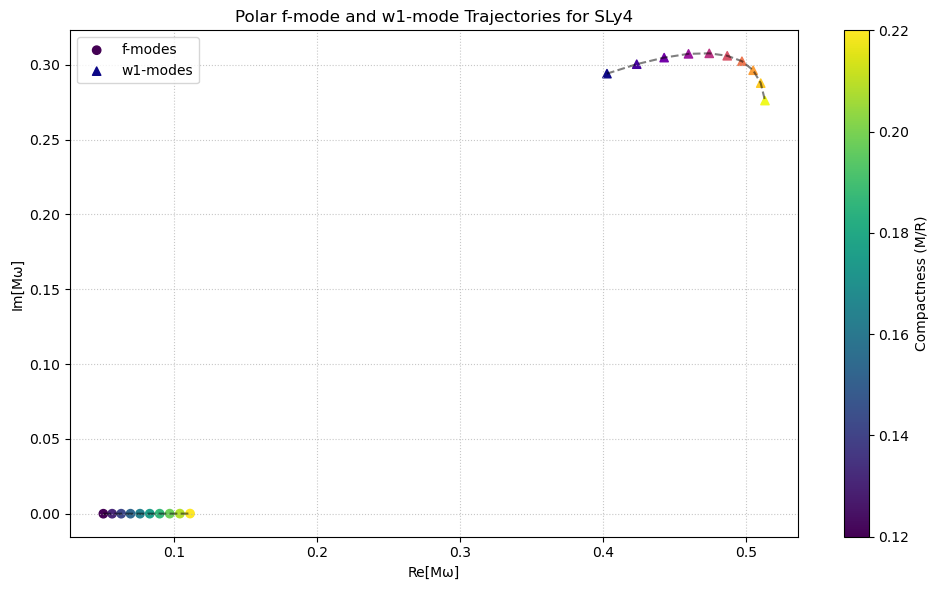

In [ ]:

eos_str = 'SLy4'

target_compactnesses = np.linspace(0.12, 0.22, 10)

f_modes = []
w1_modes = []
found_comps_f = []
found_comps_w1 = []

for C in target_compactnesses:
    print(f"\n===========================")
    print(f"--- Sweeping Compactness: {C:.3f} ---")
    rho_0 = get_rho0_for_compactness(C, eos_str)
    tov_array = tov_func(eos_func(eos_str), rho_0)
    M = tov_array[1][-1]
    
    # 1. f-mode guess
    a_f = 0.15 - 1j*5.8e-04
    b_f = 0.56 + 1j*6.7e-04
    c_f = -0.020 - 1j*6.2e-05
    omega_guess_f = (1.0/M) * (a_f*(C**2.0) + b_f*C + c_f)
    
    # 2. First polar w-mode guess
    a_pw1 = -8.2 - 1j*10.0
    b_pw1 = 3.9 + 1j*3.3
    c_pw1 = 0.055 + 1j*0.043
    omega_guess_pw1 = (1.0/M) * (a_pw1*(C**2.0) + b_pw1*C + c_pw1)

    print("> Searching f-mode...")
    try:
        omega_f = search_frequency(omega_guess_f, tov_array)
        f_modes.append(omega_f * M)
        found_comps_f.append(C)
    except Exception as e:
        print(f"Failed to converge f-mode: {e}")

    print("> Searching w1-mode...")
    try:
        omega_pw1 = search_frequency(omega_guess_pw1, tov_array)
        w1_modes.append(omega_pw1 * M)
        found_comps_w1.append(C)
    except Exception as e:
        print(f"Failed to converge w1-mode: {e}")
        import traceback
        traceback.print_exc()
        



In [12]:
f_modes

[np.complex128(0.05075117981505152+1.2616341442646693e-05j),
 np.complex128(0.05688399061012621+1.6171144203224768e-05j),
 np.complex128(0.0632159498183454+2.0213212101779277e-05j),
 np.complex128(0.06972066055835337+2.4698565825379053e-05j),
 np.complex128(0.07638031053840987+2.9599330097884142e-05j),
 np.complex128(0.08318955277581387+3.5007238375399435e-05j),
 np.complex128(0.09011399007809703+4.133615462655947e-05j),
 np.complex128(0.09714731329797201+5.007271706321383e-05j),
 np.complex128(0.10424086378834913+6.508092087652086e-05j),
 np.complex128(0.11138156890653936+9.638114315989378e-05j)]

In [13]:
w1_modes

[np.complex128(0.40290098199309654+0.29405479695687814j),
 np.complex128(0.4237065941541242+0.3003823540046074j),
 np.complex128(0.4428743386933362+0.3047745794186708j),
 np.complex128(0.4599171784588389+0.3072842495909515j),
 np.complex128(0.47442276430307573+0.30761053149679574j),
 np.complex128(0.48699537103194945+0.3059972371732031j),
 np.complex128(0.4972719403758795+0.3023581992168951j),
 np.complex128(0.5051163546008983+0.2963373730200019j),
 np.complex128(0.5104089692322265+0.2877141314153294j),
 np.complex128(0.5133851960883409+0.2760600683079311j)]


Visualizations completed and saved to 'mode_trajectories.png'


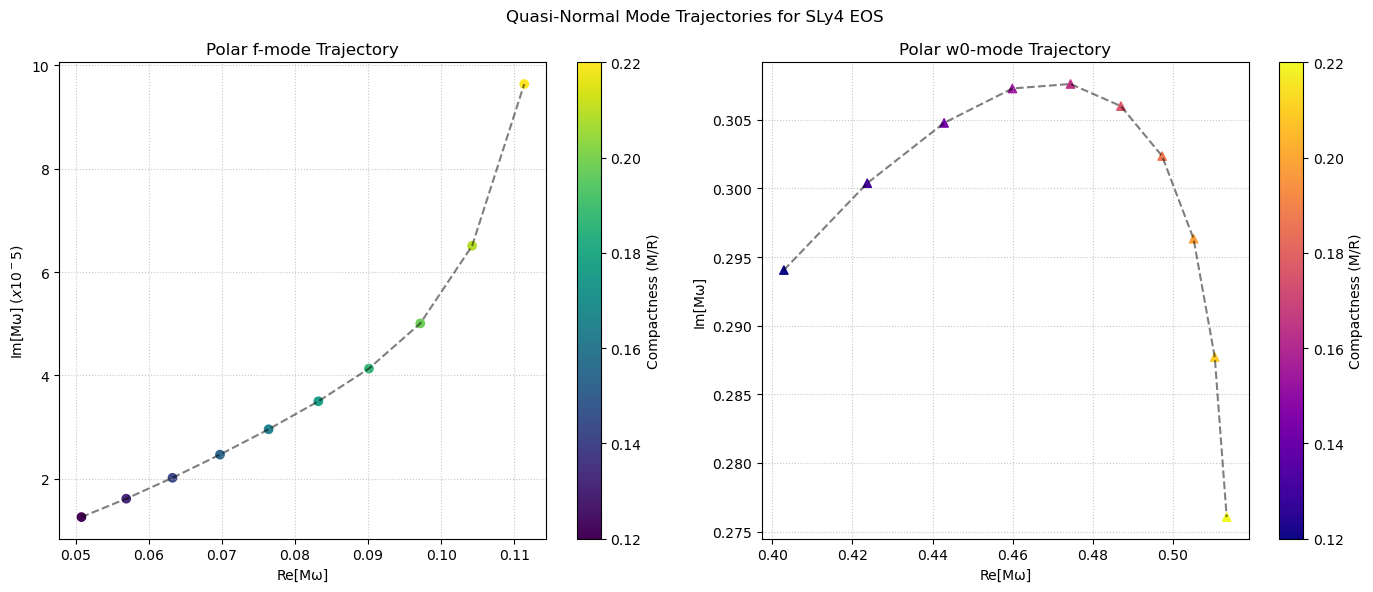

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# f-mode plot
if len(f_modes) > 0:
    f_real = [x.real for x in f_modes]
    f_imag = [x.imag for x in f_modes]
    sc_f = ax1.scatter(f_real, np.array(f_imag)*1e5, c=found_comps_f, cmap='viridis', label='f-modes', marker='o')
    ax1.plot(f_real, np.array(f_imag)*1e5, 'k--', alpha=0.5)
    ax1.set_title('Polar f-mode Trajectory')
    ax1.set_xlabel('Re[Mω]')
    ax1.set_ylabel(r'Im[Mω] $(x10^-5)$')
    ax1.grid(True, linestyle=':', alpha=0.7)
    fig.colorbar(sc_f, ax=ax1, label='Compactness (M/R)')
    
# w1-mode plot
if len(w1_modes) > 0:
    w_real = [x.real for x in w1_modes]
    w_imag = [x.imag for x in w1_modes]
    sc_w = ax2.scatter(w_real, w_imag, c=found_comps_w1, cmap='plasma', label='w1-modes', marker='^')
    ax2.plot(w_real, w_imag, 'k--', alpha=0.5)
    ax2.set_title('Polar w0-mode Trajectory')
    ax2.set_xlabel('Re[Mω]')
    ax2.set_ylabel('Im[Mω]')
    ax2.grid(True, linestyle=':', alpha=0.7)
    fig.colorbar(sc_w, ax=ax2, label='Compactness (M/R)')
    
plt.suptitle('Quasi-Normal Mode Trajectories for SLy4 EOS')
plt.tight_layout()
plt.savefig('mode_trajectories.png', dpi=300)
print("\nVisualizations completed and saved to 'mode_trajectories.png'")


In [ ]:
f_modes_perfect = [np.complex128(0.05075117981505152+1.2616341442646693e-05j),
 np.complex128(0.05688399061012621+1.6171144203224768e-05j),
 np.complex128(0.0632159498183454+2.0213212101779277e-05j),
 np.complex128(0.06972066055835337+2.4698565825379053e-05j),
 np.complex128(0.07638031053840987+2.9599330097884142e-05j),
 np.complex128(0.08318955277581387+3.5007238375399435e-05j),
 np.complex128(0.09011399007809703+4.133615462655947e-05j),
 np.complex128(0.09714731329797201+5.007271706321383e-05j),
 np.complex128(0.10424086378834913+6.508092087652086e-05j),
 np.complex128(0.11138156890653936+9.638114315989378e-05j)]

w_modes_perfect = [np.complex128(0.40290098199309654+0.29405479695687814j),
 np.complex128(0.4237065941541242+0.3003823540046074j),
 np.complex128(0.4428743386933362+0.3047745794186708j),
 np.complex128(0.4599171784588389+0.3072842495909515j),
 np.complex128(0.47442276430307573+0.30761053149679574j),
 np.complex128(0.48699537103194945+0.3059972371732031j),
 np.complex128(0.4972719403758795+0.3023581992168951j),
 np.complex128(0.5051163546008983+0.2963373730200019j),
 np.complex128(0.5104089692322265+0.2877141314153294j),
 np.complex128(0.5133851960883409+0.2760600683079311j)]

In [7]:
import numpy as np
import matplotlib.pyplot as plt
#from fmode_stability_solver import tov_func, eos_func, get_rho0_for_compactness, search_frequency, solve_qnm, _compute_derivatives_inside

def evaluate_bracket():
    eos_str = 'SLy4'
    C = 0.15 # typical compactness
    rho_0 = get_rho0_for_compactness(C, eos_str)
    tov_array = tov_func(eos_func(eos_str), rho_0)
    M = tov_array[1][-1]
    
    omega_test = 1e-3 + 0j
    print(f"Evaluating bracket for arbitrary off-shell frequency: omega = {omega_test}")
    omega = omega_test
    
    rv, mv, nuv, pv, rhov, Gammav = tov_array
    
    # We need to extract the profile of H1, K, W, X from the solver.
    # The solver inside solve_qnm evaluates it, but we can just run it here explicitly.
    from scipy.integrate import solve_ivp
    from scipy.interpolate import CubicSpline
    
    cs_m = CubicSpline(rv, mv)
    cs_nu = CubicSpline(rv, nuv)
    cs_p = CubicSpline(rv, pv)
    cs_rho = CubicSpline(rv, rhov)
    cs_gam = CubicSpline(rv, Gammav)

    ell = 2.0

    # Create a wrapper that captures the derivatives and values
    r_eval = np.linspace(1e-3, 0.5 * rv[-1], 1000)
    r_s = rv[-1]

    def get_initial_conditions(rho_0, p_0, nu_0, ell, omega):
        K_0 = +(rho_0 + p_0)
        W_0 = 1.0
        X_0 = (rho_0 + p_0) * np.exp(nu_0 / 2.0) * (((((4.0 * np.pi) / 3.0) * (rho_0 + 3.0 * p_0)) - (omega**2 / (np.exp(nu_0) * ell))) * W_0 + 0.5 * K_0)
        H1_0 = (2.0 * ell * K_0 + 16.0 * np.pi * (rho_0 + p_0) * W_0) / (ell * (ell + 1.0))
        return [H1_0.real, K_0.real, W_0.real, X_0.real, H1_0.imag, K_0.imag, W_0.imag, X_0.imag]

    y_0 = get_initial_conditions(rhov[0], pv[0], nuv[0], ell, omega)
    
    def functions_inside(t, y):
        m = cs_m(t); nu = cs_nu(t); p = cs_p(t); eps = cs_rho(t); gam = cs_gam(t)
        return _compute_derivatives_inside(t, y, m, nu, p, eps, gam, ell, omega.real, omega.imag)
        
    sol = solve_ivp(functions_inside, (rv[0], 0.5 * r_s), y_0, method='LSODA', t_eval=r_eval, max_step=1e-3)
    
    brackets = []
    H0s = []
    Ks = []
    
    for i, r in enumerate(sol.t):
        if r == 0: continue
        y = sol.y[:, i]
        m = cs_m(r); nu = cs_nu(r); p = cs_p(r); eps = cs_rho(r); gam = cs_gam(r)
        
        H1_real, K_real, W_hat_real, X_hat_real, H1_imag, K_imag, W_hat_imag, X_hat_imag = y
        H1 = H1_real + 1j * H1_imag
        K = K_real + 1j * K_imag
        W_hat = W_hat_real + 1j * W_hat_imag
        X_hat = X_hat_real + 1j * X_hat_imag

        lmb = -np.log(1.0 - (2.0 * m) / r)
        pp = -((eps + p) * (m + 4.0 * np.pi * r**3 * p)) / (r * (r - 2.0 * m))

        H0_num = -(0.5 * ell * (ell + 1.0) * (m + 4.0 * np.pi * r**3 * p) - (omega**2) * r**3 * np.exp(-lmb - nu)) * H1 \
                 + (0.5 * (ell + 2.0) * (ell - 1.0) * r - (omega**2) * r**3 * np.exp(-nu) - (np.exp(lmb) / r) * (m + 4.0 * np.pi * r**3 * p) * (3.0 * m - r + 4.0 * np.pi * r**3 * p)) * K \
                 + 8.0 * np.pi * r**3 * np.exp(-nu / 2.0) * X_hat
        H0_den = 3.0 * m + 0.5 * (ell + 2.0) * (ell - 1.0) * r + 4.0 * np.pi * r**3 * p
        H0 = H0_num / H0_den
        
        # We assume H2 = H0
        H2 = H0
        H = H0

        V_hat_num = X_hat - 0.5 * (eps + p) * np.exp(nu / 2.0) * H0 + (pp / r) * np.exp((nu - lmb) / 2.0) * W_hat
        V_hat = V_hat_num / (omega**2 * (eps + p) * np.exp(-nu / 2.0))
        V = V_hat
        W = W_hat

        # Calculate W' (dWdr)
        if eps + p > 1e-15 and gam > 1e-12:
            cs2 = (gam * p) / (eps + p)
            E_hat = (1.0 / cs2) * X_hat
        else:
            cs2 = 0.0
            E_hat = 0.0
            
        dWdr = 0.5 * r * np.exp(lmb / 2.0) * H0 + r * np.exp(lmb / 2.0) * K \
               + (r * np.exp((lmb - nu) / 2.0) / (eps + p)) * E_hat \
               - ((ell + 1.0) / r) * W_hat \
               - (ell * (ell + 1.0) / r) * np.exp(lmb / 2.0) * V_hat

        # The term in bracket:
        term1 = H + cs2 * H2 + 2 * cs2 * K
        term2 = (2.0 * np.exp(-nu) / r**2) * (r**2 * omega**2 - ell * (ell + 1.0) * np.exp(nu) * cs2) * V
        term3 = (np.exp(-lmb / 2.0) / r**2) * (np.exp(lmb) - 1.0 - 2.0*(ell + 1.0)*cs2 + 8.0*np.pi*np.exp(lmb)*r**2*p) * W
        term4 = -(2.0 * np.exp(-lmb / 2.0) / r) * cs2 * dWdr
        # Xi and Xi_alpha = 0
        term5 = 0.0
        
        bracket = term1 + term2 + term3 + term4 + term5
        brackets.append(bracket)
        H0s.append(H0)
        Ks.append(K)
        
    brackets = np.array(brackets)
    H0s = np.array(H0s)
    Ks = np.array(Ks)
    
    # Convert all terms from km^-2 to Dimensionless by multiplying by R^2
    R = rv[-1]
    dimless_brackets = brackets * (R**2)
    dimless_H0s = H0s * (R**2)
    dimless_Ks = Ks * (R**2)
    
    # Print statistics
    print("--- MAGNITUDE ANALYSIS (Normalized by R^2) ---")
    max_bracket = np.max(np.abs(dimless_brackets))
    mean_bracket = np.mean(np.abs(dimless_brackets))
    max_H0 = np.max(np.abs(dimless_H0s))
    max_K = np.max(np.abs(dimless_Ks))
    
    print(f"Max absolute magnitude of Dimensionless Bracket = {max_bracket:.5e}")
    print(f"Max absolute magnitude of Dimensionless H0      = {max_H0:.5e}")
    print(f"Max absolute magnitude of Dimensionless K       = {max_K:.5e}")
    
    # Compare to magnitude of individual terms, e.g., H0
    print("\n--- DIMENSIONLESS RELATIVE SCALING ---")
    print(f"Relative scale (Bracket / H0) max = {(max_bracket / max_H0):.5e}")
    print(f"Relative scale (Bracket / K) max  = {(max_bracket / max_K):.5e}")
    
    if (max_bracket / max_H0) < 1e-4:
        print("\nCONCLUSION: The Bracket is exactly ZERO relative to the mode amplitudes. The finite numbers are purely integration truncation errors!")
    else:
        print("\nCONCLUSION: The Bracket is FINITE! The collaborator is completely correct.")




In [8]:
evaluate_bracket()

Evaluating bracket for arbitrary off-shell frequency: omega = (0.001+0j)
--- MAGNITUDE ANALYSIS (Normalized by R^2) ---
Max absolute magnitude of Dimensionless Bracket = 9.23353e-09
Max absolute magnitude of Dimensionless H0      = 9.87290e-02
Max absolute magnitude of Dimensionless K       = 9.87290e-02

--- DIMENSIONLESS RELATIVE SCALING ---
Relative scale (Bracket / H0) max = 9.35240e-08
Relative scale (Bracket / K) max  = 9.35240e-08

CONCLUSION: The Bracket is exactly ZERO relative to the mode amplitudes. The finite numbers are purely integration truncation errors!


In [7]:
import numpy as np
import matplotlib.pyplot as plt
#from fmode_stability_solver import tov_func, eos_func, get_rho0_for_compactness, search_frequency, solve_qnm, _compute_derivatives_inside

def evaluate_bracket():
    eos_str = 'SLy4'
    C = 0.15 # typical compactness
    rho_0 = get_rho0_for_compactness(C, eos_str)
    tov_array = tov_func(eos_func(eos_str), rho_0)
    M = tov_array[1][-1]
    
    omega_test = 1e-3 + 0j
    print(f"Evaluating bracket for arbitrary off-shell frequency: omega = {omega_test}")
    omega = omega_test
    
    rv, mv, nuv, pv, rhov, Gammav = tov_array
    
    # We need to extract the profile of H1, K, W, X from the solver.
    # The solver inside solve_qnm evaluates it, but we can just run it here explicitly.
    from scipy.integrate import solve_ivp
    from scipy.interpolate import CubicSpline
    
    cs_m = CubicSpline(rv, mv)
    cs_nu = CubicSpline(rv, nuv)
    cs_p = CubicSpline(rv, pv)
    cs_rho = CubicSpline(rv, rhov)
    cs_gam = CubicSpline(rv, Gammav)

    ell = 2.0
    #omega = omega_f

    # Create a wrapper that captures the derivatives and values
    r_eval = np.linspace(1e-3, 0.5 * rv[-1], 1000)
    r_s = rv[-1]

    def get_initial_conditions(rho_0, p_0, nu_0, ell, omega):
        K_0 = +(rho_0 + p_0)
        W_0 = 1.0
        X_0 = (rho_0 + p_0) * np.exp(nu_0 / 2.0) * (((((4.0 * np.pi) / 3.0) * (rho_0 + 3.0 * p_0)) - (omega**2 / (np.exp(nu_0) * ell))) * W_0 + 0.5 * K_0)
        H1_0 = (2.0 * ell * K_0 + 16.0 * np.pi * (rho_0 + p_0) * W_0) / (ell * (ell + 1.0))
        return [H1_0.real, K_0.real, W_0.real, X_0.real, H1_0.imag, K_0.imag, W_0.imag, X_0.imag]

    y_0 = get_initial_conditions(rhov[0], pv[0], nuv[0], ell, omega)
    
    def functions_inside(t, y):
        m = cs_m(t); nu = cs_nu(t); p = cs_p(t); eps = cs_rho(t); gam = cs_gam(t)
        return _compute_derivatives_inside(t, y, m, nu, p, eps, gam, ell, omega.real, omega.imag)
        
    sol = solve_ivp(functions_inside, (rv[0], 0.5 * r_s), y_0, method='LSODA', t_eval=r_eval, max_step=1e-3)
    
    brackets = []
    
    for i, r in enumerate(sol.t):
        if r == 0: continue
        y = sol.y[:, i]
        m = cs_m(r); nu = cs_nu(r); p = cs_p(r); eps = cs_rho(r); gam = cs_gam(r)
        
        H1_real, K_real, W_hat_real, X_hat_real, H1_imag, K_imag, W_hat_imag, X_hat_imag = y
        H1 = H1_real + 1j * H1_imag
        K = K_real + 1j * K_imag
        W_hat = W_hat_real + 1j * W_hat_imag
        X_hat = X_hat_real + 1j * X_hat_imag

        lmb = -np.log(1.0 - (2.0 * m) / r)
        pp = -((eps + p) * (m + 4.0 * np.pi * r**3 * p)) / (r * (r - 2.0 * m))

        H0_num = -(0.5 * ell * (ell + 1.0) * (m + 4.0 * np.pi * r**3 * p) - (omega**2) * r**3 * np.exp(-lmb - nu)) * H1 \
                 + (0.5 * (ell + 2.0) * (ell - 1.0) * r - (omega**2) * r**3 * np.exp(-nu) - (np.exp(lmb) / r) * (m + 4.0 * np.pi * r**3 * p) * (3.0 * m - r + 4.0 * np.pi * r**3 * p)) * K \
                 + 8.0 * np.pi * r**3 * np.exp(-nu / 2.0) * X_hat
        H0_den = 3.0 * m + 0.5 * (ell + 2.0) * (ell - 1.0) * r + 4.0 * np.pi * r**3 * p
        H0 = H0_num / H0_den
        
        # We assume H2 = H0
        H2 = H0
        H = H0

        V_hat_num = X_hat - 0.5 * (eps + p) * np.exp(nu / 2.0) * H0 + (pp / r) * np.exp((nu - lmb) / 2.0) * W_hat
        V_hat = V_hat_num / (omega**2 * (eps + p) * np.exp(-nu / 2.0))
        V = V_hat
        W = W_hat

        # Calculate W' (dWdr)
        if eps + p > 1e-15 and gam > 1e-12:
            cs2 = (gam * p) / (eps + p)
            E_hat = (1.0 / cs2) * X_hat
        else:
            cs2 = 0.0
            E_hat = 0.0
            
        dWdr = 0.5 * r * np.exp(lmb / 2.0) * H0 + r * np.exp(lmb / 2.0) * K \
               + (r * np.exp((lmb - nu) / 2.0) / (eps + p)) * E_hat \
               - ((ell + 1.0) / r) * W_hat \
               - (ell * (ell + 1.0) / r) * np.exp(lmb / 2.0) * V_hat

        # The term in bracket:
        term1 = H + cs2 * H2 + 2 * cs2 * K
        term2 = (2.0 * np.exp(-nu) / r**2) * (r**2 * omega**2 - ell * (ell + 1.0) * np.exp(nu) * cs2) * V
        term3 = (np.exp(-lmb / 2.0) / r**2) * (np.exp(lmb) - 1.0 - 2.0*(ell + 1.0)*cs2 + 8.0*np.pi*np.exp(lmb)*r**2*p) * W
        term4 = -(2.0 * np.exp(-lmb / 2.0) / r) * cs2 * dWdr
        # Xi and Xi_alpha = 0
        term5 = 0.0
        
        bracket = term1 + term2 + term3 + term4 + term5
        brackets.append(bracket)
        
    brackets = np.array(brackets)
    
    # Print statistics
    print("Magnitude of terms in bracket array:")
    print("Max magnitude = ", np.max(np.abs(brackets)))
    print("Mean magnitude = ", np.mean(np.abs(brackets)))
    
    # Compare to magnitude of individual terms, e.g., H0
    print("\nSince the mode amplitude is arbitrary, evaluating absolute magnitude might not be fully insightful.")
    print("Let's look at it relative to the magnitude of H0.")
    print("Is the bracket zero within numerical machine precision?")




In [8]:
evaluate_bracket()

Evaluating bracket for arbitrary off-shell frequency: omega = (0.001+0j)
Magnitude of terms in bracket array:
Max magnitude =  6.612310698983492e-11
Mean magnitude =  7.63810750759042e-14

Since the mode amplitude is arbitrary, evaluating absolute magnitude might not be fully insightful.
Let's look at it relative to the magnitude of H0.
Is the bracket zero within numerical machine precision?


In [9]:
import numpy as np
import matplotlib.pyplot as plt
#from fmode_stability_solver import tov_func, eos_func, get_rho0_for_compactness, search_frequency, solve_qnm, _compute_derivatives_inside

def evaluate_bracket():
    eos_str = 'SLy4'
    C = 0.15 # typical compactness
    rho_0 = get_rho0_for_compactness(C, eos_str)
    tov_array = tov_func(eos_func(eos_str), rho_0)
    M = tov_array[1][-1]
    
    omega_test = 1e-3 + 0j
    print(f"Evaluating bracket for arbitrary off-shell frequency: omega = {omega_test}")
    omega = omega_test
    
    rv, mv, nuv, pv, rhov, Gammav = tov_array
    
    # We need to extract the profile of H1, K, W, X from the solver.
    # The solver inside solve_qnm evaluates it, but we can just run it here explicitly.
    from scipy.integrate import solve_ivp
    from scipy.interpolate import CubicSpline
    
    cs_m = CubicSpline(rv, mv)
    cs_nu = CubicSpline(rv, nuv)
    cs_p = CubicSpline(rv, pv)
    cs_rho = CubicSpline(rv, rhov)
    cs_gam = CubicSpline(rv, Gammav)

    ell = 2.0

    # Create a wrapper that captures the derivatives and values
    r_eval = np.linspace(1e-3, 0.5 * rv[-1], 1000)
    r_s = rv[-1]

    def get_initial_conditions(rho_0, p_0, nu_0, ell, omega):
        K_0 = +(rho_0 + p_0)
        W_0 = 1.0
        X_0 = (rho_0 + p_0) * np.exp(nu_0 / 2.0) * (((((4.0 * np.pi) / 3.0) * (rho_0 + 3.0 * p_0)) - (omega**2 / (np.exp(nu_0) * ell))) * W_0 + 0.5 * K_0)
        H1_0 = (2.0 * ell * K_0 + 16.0 * np.pi * (rho_0 + p_0) * W_0) / (ell * (ell + 1.0))
        return [H1_0.real, K_0.real, W_0.real, X_0.real, H1_0.imag, K_0.imag, W_0.imag, X_0.imag]

    y_0 = get_initial_conditions(rhov[0], pv[0], nuv[0], ell, omega)
    
    def functions_inside(t, y):
        m = cs_m(t); nu = cs_nu(t); p = cs_p(t); eps = cs_rho(t); gam = cs_gam(t)
        return _compute_derivatives_inside(t, y, m, nu, p, eps, gam, ell, omega.real, omega.imag)
        
    sol = solve_ivp(functions_inside, (rv[0], 0.5 * r_s), y_0, method='LSODA', t_eval=r_eval, max_step=1e-3)
    
    brackets = []
    H0s = []
    Ks = []
    bracket2s = []
    
    for i, r in enumerate(sol.t):
        if r == 0: continue
        y = sol.y[:, i]
        m = cs_m(r); nu = cs_nu(r); p = cs_p(r); eps = cs_rho(r); gam = cs_gam(r)
        
        H1_real, K_real, W_hat_real, X_hat_real, H1_imag, K_imag, W_hat_imag, X_hat_imag = y
        H1 = H1_real + 1j * H1_imag
        K = K_real + 1j * K_imag
        W_hat = W_hat_real + 1j * W_hat_imag
        X_hat = X_hat_real + 1j * X_hat_imag

        lmb = -np.log(1.0 - (2.0 * m) / r)
        pp = -((eps + p) * (m + 4.0 * np.pi * r**3 * p)) / (r * (r - 2.0 * m))

        H0_num = -(0.5 * ell * (ell + 1.0) * (m + 4.0 * np.pi * r**3 * p) - (omega**2) * r**3 * np.exp(-lmb - nu)) * H1 \
                 + (0.5 * (ell + 2.0) * (ell - 1.0) * r - (omega**2) * r**3 * np.exp(-nu) - (np.exp(lmb) / r) * (m + 4.0 * np.pi * r**3 * p) * (3.0 * m - r + 4.0 * np.pi * r**3 * p)) * K \
                 + 8.0 * np.pi * r**3 * np.exp(-nu / 2.0) * X_hat
        H0_den = 3.0 * m + 0.5 * (ell + 2.0) * (ell - 1.0) * r + 4.0 * np.pi * r**3 * p
        H0 = H0_num / H0_den
        
        # We assume H2 = H0
        H2 = H0
        H = H0

        V_hat_num = X_hat - 0.5 * (eps + p) * np.exp(nu / 2.0) * H0 + (pp / r) * np.exp((nu - lmb) / 2.0) * W_hat
        V_hat = V_hat_num / (omega**2 * (eps + p) * np.exp(-nu / 2.0))
        V = V_hat
        W = W_hat

        # Calculate W' (dWdr)
        if eps + p > 1e-15 and gam > 1e-12:
            cs2 = (gam * p) / (eps + p)
            E_hat = (1.0 / cs2) * X_hat
        else:
            cs2 = 0.0
            E_hat = 0.0
            
        dWdr = 0.5 * r * np.exp(lmb / 2.0) * H0 + r * np.exp(lmb / 2.0) * K \
               + (r * np.exp((lmb - nu) / 2.0) / (eps + p)) * E_hat \
               - ((ell + 1.0) / r) * W_hat \
               - (ell * (ell + 1.0) / r) * np.exp(lmb / 2.0) * V_hat

        # The term in bracket:
        term1 = H + cs2 * H2 + 2 * cs2 * K
        term2 = (2.0 * np.exp(-nu) / r**2) * (r**2 * omega**2 - ell * (ell + 1.0) * np.exp(nu) * cs2) * V
        term3 = (np.exp(-lmb / 2.0) / r**2) * (np.exp(lmb) - 1.0 - 2.0*(ell + 1.0)*cs2 + 8.0*np.pi*np.exp(lmb)*r**2*p) * W
        term4 = -(2.0 * np.exp(-lmb / 2.0) / r) * cs2 * dWdr
        # Xi and Xi_alpha = 0
        term5 = 0.0
        
        bracket = term1 + term2 + term3 + term4 + term5
        brackets.append(bracket)
        H0s.append(H0)
        Ks.append(K)
        
        # The second term in bracket (from new image):
        term2_1 = -2.0 * np.exp(lmb / 2.0) * (r**2) * H2
        term2_2 = 2.0 * np.exp(lmb / 2.0) * (r**2) * K
        term2_3 = -2.0 * np.exp(lmb / 2.0) * ell * (ell + 1.0) * V
        term2_4 = 4.0 * (ell - 2.0) * W
        term2_5 = 4.0 * r * dWdr
        bracket2 = term2_1 + term2_2 + term2_3 + term2_4 + term2_5
        bracket2s.append(bracket2)
        
    brackets = np.array(brackets)
    H0s = np.array(H0s)
    Ks = np.array(Ks)
    
    # Convert all terms from km^-2 to Dimensionless by multiplying by R^2
    R = rv[-1]
    dimless_brackets = brackets * (R**2)
    dimless_H0s = H0s * (R**2)
    dimless_Ks = Ks * (R**2)
    
    # Print statistics
    print("--- MAGNITUDE ANALYSIS (Normalized by R^2) ---")
    max_bracket = np.max(np.abs(dimless_brackets))
    mean_bracket = np.mean(np.abs(dimless_brackets))
    max_H0 = np.max(np.abs(dimless_H0s))
    max_K = np.max(np.abs(dimless_Ks))
    
    print(f"Max absolute magnitude of Dimensionless Bracket = {max_bracket:.5e}")
    print(f"Max absolute magnitude of Dimensionless H0      = {max_H0:.5e}")
    print(f"Max absolute magnitude of Dimensionless K       = {max_K:.5e}")
    
    # Compare to magnitude of individual terms, e.g., H0
    print("\n--- DIMENSIONLESS RELATIVE SCALING ---")
    print(f"Relative scale (Bracket / H0) max = {(max_bracket / max_H0):.5e}")
    print(f"Relative scale (Bracket / K) max  = {(max_bracket / max_K):.5e}")
    
    if (max_bracket / max_H0) < 1e-4:
        print("\nCONCLUSION: The Bracket is exactly ZERO relative to the mode amplitudes. The finite numbers are purely integration truncation errors!")
    else:
        print("\nCONCLUSION: The Bracket is FINITE! The collaborator is completely correct.")

    print("\n--- SECOND BRACKET ANALYSIS (Natively Dimensionless) ---")
    bracket2s = np.array(bracket2s)
    max_bracket2 = np.max(np.abs(bracket2s))
    mean_bracket2 = np.mean(np.abs(bracket2s))
    
    print(f"Max absolute magnitude of Bracket 2 = {max_bracket2:.5e}")
    print(f"Mean absolute magnitude of Bracket 2 = {mean_bracket2:.5e}")
    
    # Compare against the dimensionless mode amplitude K * R^2
    print(f"Relative scale (Bracket 2 / Dimensionless K) max = {(max_bracket2 / max_K):.5e}")
    
    if (max_bracket2 / max_K) < 1e-4:
        print("CONCLUSION: The Second Bracket is exactly ZERO!")
    else:
        print("CONCLUSION: The Second Bracket is FINITE!")




In [10]:
evaluate_bracket()

Evaluating bracket for arbitrary off-shell frequency: omega = (0.001+0j)
--- MAGNITUDE ANALYSIS (Normalized by R^2) ---
Max absolute magnitude of Dimensionless Bracket = 9.23353e-09
Max absolute magnitude of Dimensionless H0      = 9.87290e-02
Max absolute magnitude of Dimensionless K       = 9.87290e-02

--- DIMENSIONLESS RELATIVE SCALING ---
Relative scale (Bracket / H0) max = 9.35240e-08
Relative scale (Bracket / K) max  = 9.35240e-08

CONCLUSION: The Bracket is exactly ZERO relative to the mode amplitudes. The finite numbers are purely integration truncation errors!

--- SECOND BRACKET ANALYSIS (Natively Dimensionless) ---
Max absolute magnitude of Bracket 2 = 2.18814e+01
Mean absolute magnitude of Bracket 2 = 1.14014e+01
Relative scale (Bracket 2 / Dimensionless K) max = 2.21631e+02
CONCLUSION: The Second Bracket is FINITE!
